## Calculate coral bleaching using ERA5 data in the Kiholo region of the Hawaii

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import netCDF4
import xarray as xr

import warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

In [2]:
location = 'Kiholo'

### Read in preprocessed SST data

In [3]:
file = '/glade/derecho/scratch/kristenk/bleaching_work/Kiholo_ERA5_SST_timeseries_daily.nc'
ds = xr.open_dataset(file)

In [4]:
ds = ds.rename_dims({'valid_time':'time'})
ds = ds.drop_vars(['valid_time'])

In [5]:
times = pd.date_range(start="1980-01-01", end="2023-12-31",freq="D")
ds['time'] = times

In [6]:
nday = len(ds.time)
nday

16071

### Plot SST from a subset of data

In [7]:
ds.time

<xarray.DataArray 'time' (time: 16071)>
array(['1980-01-01T00:00:00.000000000', '1980-01-02T00:00:00.000000000',
       '1980-01-03T00:00:00.000000000', ..., '2023-12-29T00:00:00.000000000',
       '2023-12-30T00:00:00.000000000', '2023-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    latitude   float64 ...
    longitude  float64 ...
  * time       (time) datetime64[ns] 1980-01-01 1980-01-02 ... 2023-12-31

CPU times: user 9.83 ms, sys: 0 ns, total: 9.83 ms
Wall time: 9.84 ms


(23.0, 31.0)

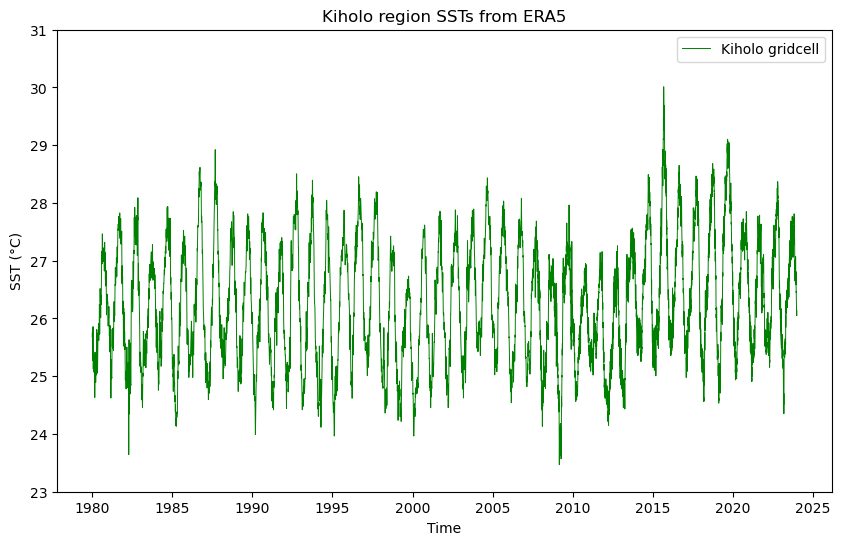

In [8]:
%%time

fig = plt.figure(figsize=(10,6))

ax = fig.add_subplot(1,1,1)
ax.set_title(location + ' region SSTs from ERA5')
ax.plot(ds.time, ds['sst'], linewidth=0.7, color='green',label=location+ ' gridcell')
ax.set(ylabel='SST (°C)',xlabel='Time')
ax.legend()
ax.set_ylim(23,31)

### Make a monthly dataset (this is needed to calculate the max monthly mean, MMM, sst over the climatological period, the 1980s)

In [9]:
ds_mon = ds.resample({'time':'M'}).mean(dim='time').compute()

### Calculate static climatology (Maximum monthly mean MMM temp) - this is used to make climatologies

#### Find maximum monthly means over this period

In [10]:
### Make some empty arrays
ymax = np.zeros((10,),dtype=float) ### year maxes over climatological period

### cycle through each year of the period of our static climatology
for y in range(0,10):

    ### find the index of the first month of this year
    m1 = y * 12 ## find the index of the first month of this year

    ### put the maximum temperature from this year into the ymax array
    ymax[y] = np.max(ds_mon.sst.values[m1:m1+12])

    print(y, ymax[y])
    
### take a mean and standard deviation of ymax values
MMM = np.mean(ymax) 
MMMstd = np.std(ymax)
    
print("For the static climatology:")
print("Max monthly mean temp is ", MMM)
print("Standard deviation of MMM is", MMMstd)

0 27.18131446838379
1 27.622968673706055
2 27.57571029663086
3 26.954668045043945
4 27.667200088500977
5 27.276334762573242
6 28.477529525756836
7 28.342008590698242
8 27.452791213989258
9 27.53504753112793
For the static climatology:
Max monthly mean temp is  27.608557319641115
Standard deviation of MMM is 0.45254118971522667


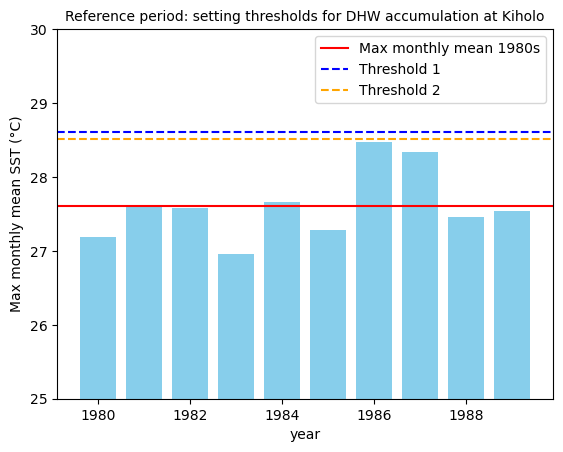

In [11]:
plt.bar(np.arange(1980,1990), ymax, color='skyblue')
plt.title('Reference period: setting thresholds for DHW accumulation at '+location, fontsize=10)
plt.ylim(25,30)
plt.axhline(MMM,color='red', label='Max monthly mean 1980s')
plt.axhline(MMM+1,linestyle='--',label='Threshold 1',color='blue')
plt.axhline(MMM+2*MMMstd,linestyle='--',label='Threshold 2',color='orange')
plt.ylabel('Max monthly mean SST (°C)')
plt.xlabel('year')
plt.legend();

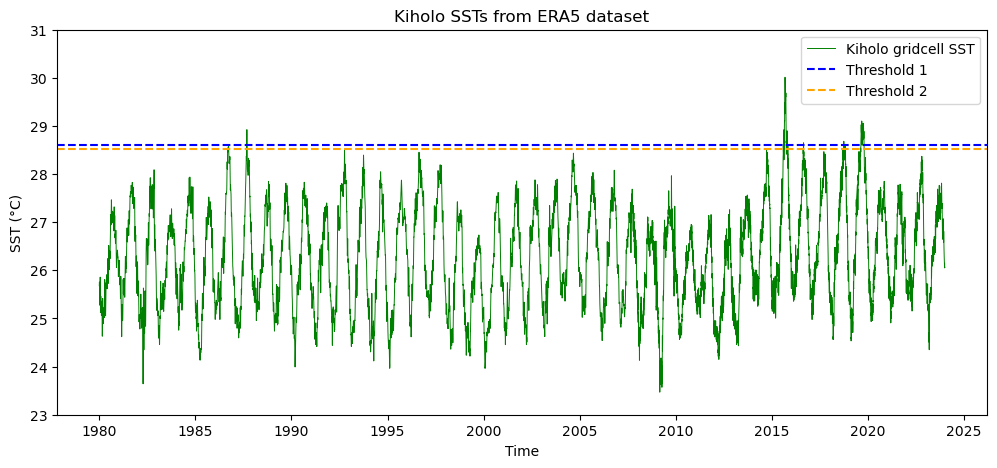

In [12]:
fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(1,1,1)
ax.set_title(location+' SSTs from ERA5 dataset')
ax.plot(ds.time, ds['sst'], linewidth=0.7, color='green',label=location +' gridcell SST')
plt.axhline(MMM+1,linestyle='--',label='Threshold 1',color='blue')
plt.axhline(MMM+2*MMMstd,linestyle='--',label='Threshold 2',color='orange')
ax.set(ylabel='SST (°C)',xlabel='Time')
ax.legend()
ax.set_ylim(23,31);

### Calculate Degree Heating Weeks (DHW) with the daily data

https://coralreefwatch.noaa.gov/product/5km/methodology.php#dhw

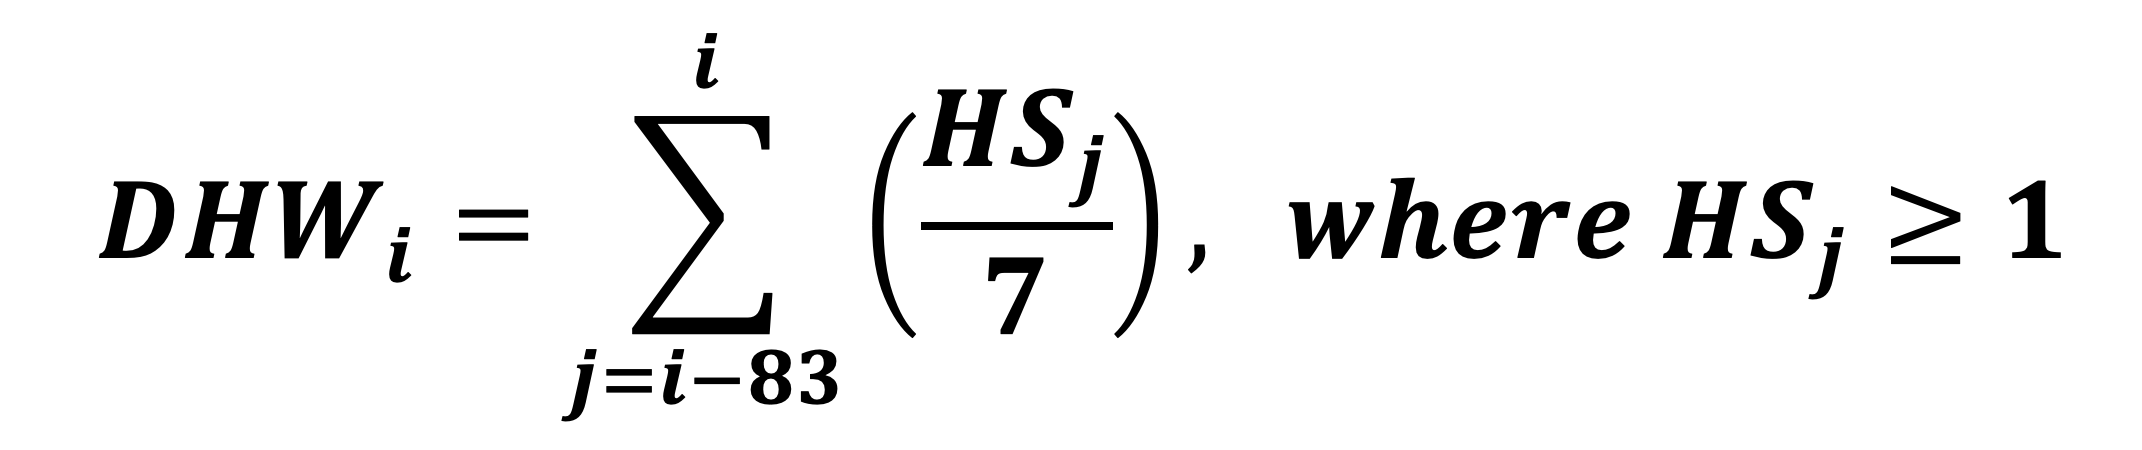

### calculate DHW in 2 ways: using the standard 1°C threshold and using the variability based threshold (2*MMMstd; Boylan & Kleypas 2008)

In [13]:
#set up empty dataset for DHW 
DHW1 = np.zeros((nday),dtype=float) #standard way (Coral reef watch)
DHW2 = np.zeros((nday),dtype=float) #variability-based way 
hotspot_anoms1 = np.zeros((nday),dtype=float)
hotspot_anoms2 = np.zeros((nday),dtype=float)

### the additional temperature threshold beyond climatological maximum that is included in DHM
threshold1 = 1
threshold2 = 2*MMMstd

### cycle through all the days
for d in range(0,nday):

    ### now calculate how much this day exceeds the threshold, otherwise anomaly is zero
    if ds.sst[d] > MMM + threshold1:
        hotspot_anoms1[d] = ds.sst[d] - (MMM + threshold1)

    if ds.sst[d] > MMM + threshold2:
        hotspot_anoms2[d] = ds.sst[d] - (MMM + threshold2)

### sum up DHW, start 84 days into the dataset since this is the DHW period
### cycle through all the days, summing over 12 weeks prior (84 days)

for d in range(84,nday):
    
    DHW1[d] = np.sum((hotspot_anoms1[d-84:d+1])/7)
    DHW2[d] = np.sum((hotspot_anoms2[d-84:d+1])/7)

### convert DHW to xarray and add it to the original dataset
ds['DHW1'] = xr.DataArray(DHW1,dims=('time'))
ds['DHW2'] = xr.DataArray(DHW2,dims=('time'))
ds['HS_anoms1'] = xr.DataArray(hotspot_anoms1,dims=('time'))
ds['HS_anoms2'] = xr.DataArray(hotspot_anoms2,dims=('time'))

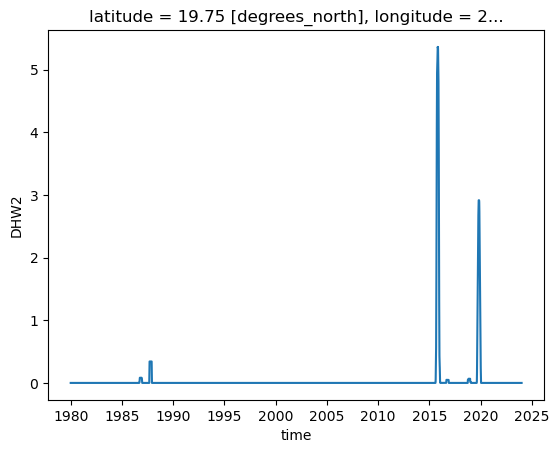

In [14]:
ds['DHW2'].plot()

### Calculate max level of bleaching within each calendar year

This is where we can choose eith the standard 1°C bleaching threshold or a variability-based threshold (2*SD) for bleaching

In [15]:
nyear = 44

In [16]:
ds_bleach = xr.Dataset() #this dataset will have yearly time dim

In [17]:
### create empty arrays for bleaching indices, etc
bleach1 = np.zeros((nyear),dtype=int) 
bleach2 = np.zeros((nyear),dtype=int)
max_DHW_year1 = np.zeros((nyear),dtype=float)
max_DHW_year2 = np.zeros((nyear),dtype=float)
days_with_bleaching1 = np.zeros((nyear),dtype=int) #when DHW >= 4
days_with_bleaching2 = np.zeros((nyear),dtype=int) #when DHW >= 4


### cycle through all the years, calculating max DHW for that year, the max bleaching index, and the number of days with >4 DHWs

ts = 0 #yearly counter
i = 0 #daily counter

for y in np.arange(1980,2024,1):

    #specify number of days in this year (determine if it's a leap year)
    if y==1980 or y==1984 or y==1988 or y==1992 or y==1996 or y==2000 or y==2004 or y==2008 or y==2012 or y==2016 or y==2020 or y==2024:
        ndays = 366
    else:
        ndays=365

    ### find out max degree heating weeks for this particular year
    max_DHW_year1[ts] = np.max(ds.DHW1[i:i+ndays])
    max_DHW_year2[ts] = np.max(ds.DHW2[i:i+ndays])
    
    bleach1[ts] = int(max_DHW_year1[ts]/4)
    bleach2[ts] = int(max_DHW_year2[ts]/4)
    
    ### count of the number of days with a DHW >= 4
    days_with_bleaching1[ts] = np.count_nonzero(ds.DHW1[i:i+ndays] >= 4)
    days_with_bleaching2[ts] = np.count_nonzero(ds.DHW2[i:i+ndays] >= 4)
    
    i = i + ndays

    ts = ts + 1

ds_bleach['bleach_index_1'] = xr.DataArray(bleach1, dims=('time'))
ds_bleach['bleach_index_2'] = xr.DataArray(bleach2, dims=('time'))

ds_bleach['num_days_bleach_1'] = xr.DataArray(days_with_bleaching1, dims=('time'))
ds_bleach['num_days_bleach_2'] = xr.DataArray(days_with_bleaching2, dims=('time'))

ds_bleach['max_DHW_1'] = xr.DataArray(max_DHW_year1, dims=('time'))
ds_bleach['max_DHW_2'] = xr.DataArray(max_DHW_year2, dims=('time'))

#ds_bleach['time'] = np.arange(1995,2025,1)

In [18]:
ds_bleach

<xarray.Dataset>
Dimensions:            (time: 44)
Dimensions without coordinates: time
Data variables:
    bleach_index_1     (time) int64 0 0 0 0 0 0 0 0 0 0 ... 0 1 0 0 0 0 0 0 0 0
    bleach_index_2     (time) int64 0 0 0 0 0 0 0 0 0 0 ... 0 1 0 0 0 0 0 0 0 0
    num_days_bleach_1  (time) int64 0 0 0 0 0 0 0 0 0 0 ... 0 58 0 0 0 0 0 0 0 0
    num_days_bleach_2  (time) int64 0 0 0 0 0 0 0 0 0 0 ... 0 68 0 0 0 0 0 0 0 0
    max_DHW_1          (time) float64 0.0 0.0 0.0 0.0 0.0 ... 0.2966 0.0 0.0 0.0
    max_DHW_2          (time) float64 0.0 0.0 0.0 0.0 0.0 ... 0.4419 0.0 0.0 0.0

### Make some plots of the results

In [19]:
ds_bleach

<xarray.Dataset>
Dimensions:            (time: 44)
Dimensions without coordinates: time
Data variables:
    bleach_index_1     (time) int64 0 0 0 0 0 0 0 0 0 0 ... 0 1 0 0 0 0 0 0 0 0
    bleach_index_2     (time) int64 0 0 0 0 0 0 0 0 0 0 ... 0 1 0 0 0 0 0 0 0 0
    num_days_bleach_1  (time) int64 0 0 0 0 0 0 0 0 0 0 ... 0 58 0 0 0 0 0 0 0 0
    num_days_bleach_2  (time) int64 0 0 0 0 0 0 0 0 0 0 ... 0 68 0 0 0 0 0 0 0 0
    max_DHW_1          (time) float64 0.0 0.0 0.0 0.0 0.0 ... 0.2966 0.0 0.0 0.0
    max_DHW_2          (time) float64 0.0 0.0 0.0 0.0 0.0 ... 0.4419 0.0 0.0 0.0

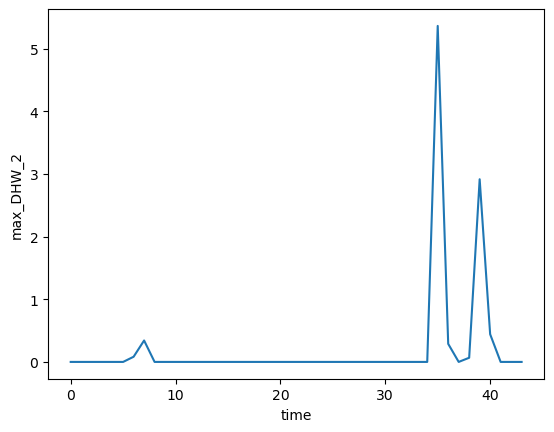

In [20]:
ds_bleach['max_DHW_2'].plot()

In [21]:
tlen=len(ds.time)

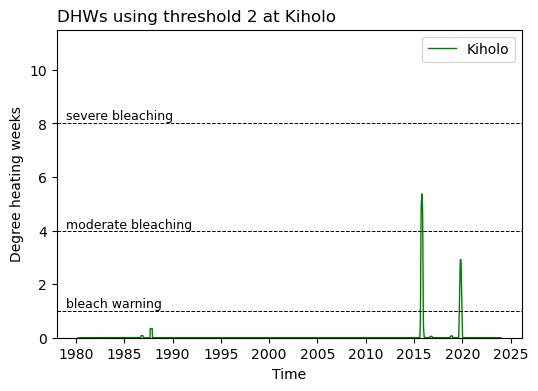

In [22]:
fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(1,1,1)
ax.set_title('DHWs using threshold 2 at '+location, loc='left')

ax.plot(ds.time.isel(time=slice(84,tlen)),ds.DHW2.isel(time=slice(84,tlen)),
        linewidth=1,label=location,color='green',zorder=0)
ax.set(ylabel='Degree heating weeks',xlabel='Time')

ax.axhline(1,color='black',linewidth=0.7,linestyle='--')
ax.text(0.02,0.10,'bleach warning',fontsize=9, transform=ax.transAxes)
ax.axhline(4,color='black',linewidth=0.7,linestyle='--')
ax.text(0.02,0.355,'moderate bleaching',fontsize=9, transform=ax.transAxes)
ax.axhline(8,color='black',linewidth=0.7,linestyle='--')
ax.text(0.02,0.71,'severe bleaching',fontsize=9, transform=ax.transAxes)

ax.legend()
ax.set_ylim(0,11.5);

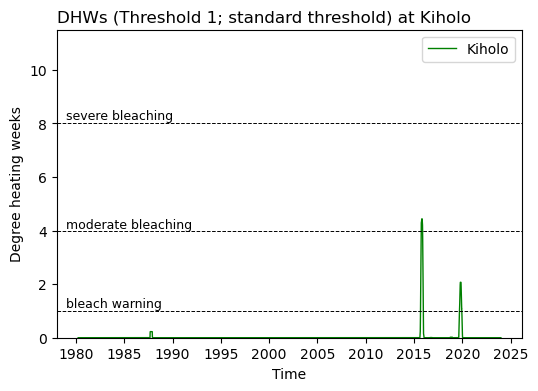

In [23]:
fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(1,1,1)
ax.set_title('DHWs (Threshold 1; standard threshold) at '+location, loc='left')

ax.plot(ds.time.isel(time=slice(84,tlen)),ds.DHW1.isel(time=slice(84,tlen)),
        linewidth=1,label=location,color='green',zorder=0)
ax.set(ylabel='Degree heating weeks',xlabel='Time')


ax.axhline(1,color='black',linewidth=0.7,linestyle='--')
ax.text(0.02,0.10,'bleach warning',fontsize=9, transform=ax.transAxes)
ax.axhline(4,color='black',linewidth=0.7,linestyle='--')
ax.text(0.02,0.355,'moderate bleaching',fontsize=9, transform=ax.transAxes)
ax.axhline(8,color='black',linewidth=0.7,linestyle='--')
ax.text(0.02,0.71,'severe bleaching',fontsize=9, transform=ax.transAxes)

ax.legend()
ax.set_ylim(0,11.5);

In [24]:
ds.to_netcdf('/glade/derecho/scratch/kristenk/bleaching_work/dialy_coral_bleaching_ts_'+location+'.nc', mode='w')